In [145]:
import pandas as pd

file_path = "/Users/anjalikaarora/Desktop/P of QCF/fiserv-capstone/data/processed_data/splits/00_full_dataset.csv"

df = pd.read_csv(file_path)

df.head()

,Period,Geo,Sector Name,Sub-Sector Name,Real Sales Index - SA_normalized,Transactional Index - SA_normalized,Real Sales Index - NSA_normalized,Transactional Index - NSA_normalized,Real Sales MOM % - SA_normalized,Real Sales YOY % - SA_normalized,...,CrudeOilPrices_normalized_YoY_normalized,ImportPriceIndex_normalized_YoY_normalized,Income_normalized_YoY_normalized,JoltsQuitsRate_normalized_YoY_normalized,MonetaryCPI_normalized_YoY_normalized,PersonalConsumptionExpenditures_normalized_YoY_normalized,Unemployment_normalized_YoY_normalized,USNaturalGasCompositePrice_normalized_YoY_normalized,Oil_ImportPrice_interaction,Unemployment_Income_interaction
0,2019-01-01,AK,ALL,ALL,0.259101,0.264438,0.192454,0.162304,-0.055139,0.009152,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.254578,0.516182
1,2019-02-01,AK,ALL,ALL,0.254159,0.259978,0.184525,0.158606,-0.234379,0.009152,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.870159,0.660978
2,2019-03-01,AK,ALL,ALL,0.257680,0.264121,0.234942,0.197608,0.075009,0.009152,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.612665,0.653077
3,2019-04-01,AK,ALL,ALL,0.257422,0.263229,0.235451,0.186326,-0.064273,0.009152,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.260662,0.725947
4,2019-05-01,AK,ALL,ALL,0.263010,0.265675,0.292571,0.214637,0.148075,0.009152,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.430205,0.798782


In [146]:
# Clean column names (remove hidden spaces)
df.columns = df.columns.str.strip()

# Filter for US, ALL sector, ALL subsector
filtered_df = (
    df[
        (df["Geo"] == "US") &
        (df["Sector Name"] == "ALL") &
        (df["Sub-Sector Name"] == "ALL")
    ]
    .copy()
)

# Convert Period to datetime and sort
filtered_df["Period"] = pd.to_datetime(filtered_df["Period"])
filtered_df = filtered_df.sort_values("Period").reset_index(drop=True)

filtered_df.head()

# Save to CSV
output_path = "/Users/anjalikaarora/Desktop/P of QCF/fiserv-capstone/models/us_all_sector_dataset.csv"
filtered_df.to_csv(output_path, index=False)

print("Saved successfully!")
print("Filtered DataFrame columns:", filtered_df.columns.tolist())

Saved successfully!
Filtered DataFrame columns: ['Period', 'Geo', 'Sector Name', 'Sub-Sector Name', 'Real Sales Index - SA_normalized', 'Transactional Index - SA_normalized', 'Real Sales Index - NSA_normalized', 'Transactional Index - NSA_normalized', 'Real Sales MOM % - SA_normalized', 'Real Sales YOY % - SA_normalized', 'Transaction MOM % - SA_normalized', 'Transaction YOY %  - SA_normalized', 'Real Sales MOM % - NSA_normalized', 'Real Sales YOY % - NSA_normalized', 'Transaction MOM % - NSA_normalized', 'Transaction YOY % - NSA_normalized', 'ConsumerSentimentIndex_normalized', 'CreditSpreadBAA_normalized', 'CreditSpreadGS10_normalized', 'CrudeOilPrices_normalized', 'ImportPriceIndex_normalized', 'Income_normalized', 'JoltsQuitsRate_normalized', 'MonetaryCPI_normalized', 'PersonalConsumptionExpenditures_normalized', 'Unemployment_normalized', 'USNaturalGasCompositePrice_normalized', 'Real Sales Index - SA_normalized_lag1', 'Transactional Index - SA_normalized_lag1', 'Real Sales Index 

In [147]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# =========================
# FSBI + MACRO PCE FORECASTING EQUATION
# (NOW WITH ALL TRANSACTIONAL VARS CONFIRMED)
# =========================
target = 'PersonalConsumptionExpenditures_normalized'

# ALL confirmed columns from your dataset
X_vars = [
    # FSBI Contemporaneous (20-day lead) - ALL EXIST
    'Real Sales Index - SA_normalized',
    'Transactional Index - SA_normalized',
    'Real Sales MOM % - SA_normalized', 
    'Transaction MOM % - SA_normalized',
    'Real Sales YOY % - SA_normalized',
    'Transaction YOY %  - SA_normalized',
    
    # Core Macros (lag1 for timing discipline)
    'ConsumerSentimentIndex_normalized_lag1',
    'Income_normalized_lag1',
    'Unemployment_normalized_lag1',
    'JoltsQuitsRate_normalized_lag1',
    'MonetaryCPI_normalized_lag1',
    'CrudeOilPrices_normalized_lag1',
    'ImportPriceIndex_normalized_lag1',
    'USNaturalGasCompositePrice_normalized_lag1',
    
    # Credit spreads (lag1)
    'CreditSpreadBAA_normalized_lag1',
    'CreditSpreadGS10_normalized_lag1',
    
    # Interactions
    'Oil_ImportPrice_interaction',
    'Unemployment_Income_interaction',

    # "PersonalConsumptionExpenditures_normalized_lag1",

    # "PersonalConsumptionExpenditures_normalized_MoM_normalized"
]

print(f"✅ Using ALL {len(X_vars)} confirmed columns")

# Prepare data  
data = filtered_df[X_vars + [target]].dropna()
y = data[target]
X = data[X_vars]


✅ Using ALL 18 confirmed columns


In [148]:
print(data.shape)
print(data.info())
print(data.describe().T)

(84, 19)
<class 'pandas.core.frame.DataFrame'>
Index: 84 entries, 1 to 84
Data columns (total 19 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Real Sales Index - SA_normalized            84 non-null     float64
 1   Transactional Index - SA_normalized         84 non-null     float64
 2   Real Sales MOM % - SA_normalized            84 non-null     float64
 3   Transaction MOM % - SA_normalized           84 non-null     float64
 4   Real Sales YOY % - SA_normalized            84 non-null     float64
 5   Transaction YOY %  - SA_normalized          84 non-null     float64
 6   ConsumerSentimentIndex_normalized_lag1      84 non-null     float64
 7   Income_normalized_lag1                      84 non-null     float64
 8   Unemployment_normalized_lag1                84 non-null     float64
 9   JoltsQuitsRate_normalized_lag1              84 non-null     float64
 10  MonetaryCPI_

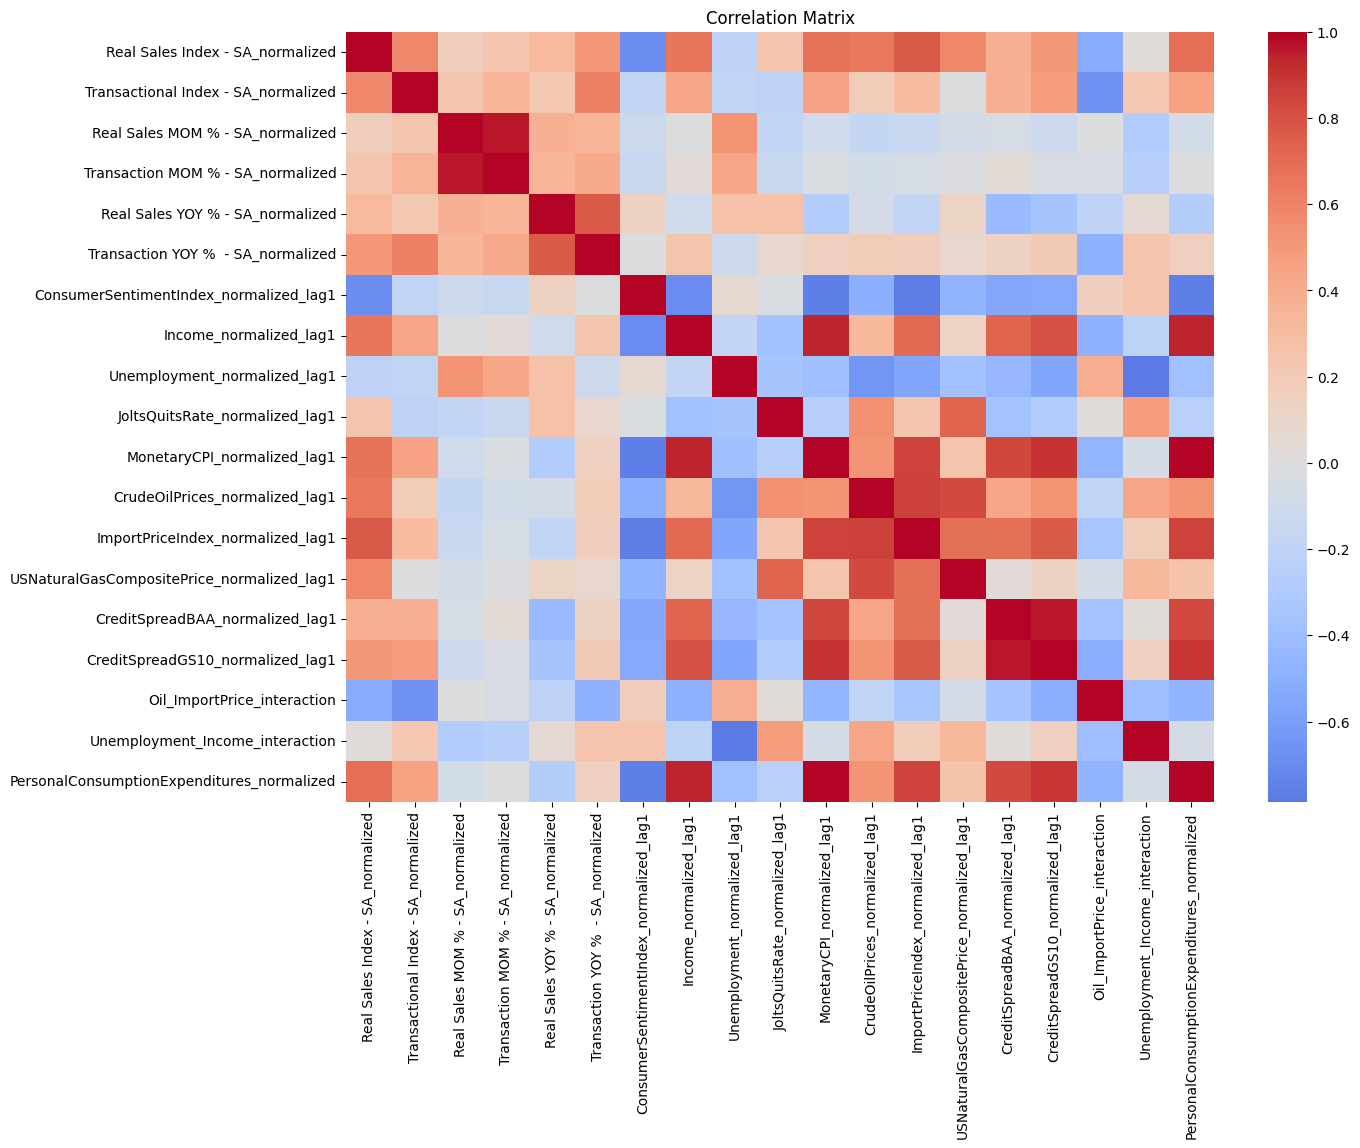

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = data.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [150]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

X_for_vif = numeric_df.drop(columns=['PersonalConsumptionExpenditures_normalized'], errors='ignore')
X_for_vif = X_for_vif.dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_for_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_for_vif.values, i)
    for i in range(X_for_vif.shape[1])
]

print(vif_data.sort_values("VIF", ascending=False))

                                       Feature          VIF
0             Real Sales Index - SA_normalized  8353.308141
1          Transactional Index - SA_normalized  5730.929956
4             Real Sales YOY % - SA_normalized   547.147631
15            CreditSpreadGS10_normalized_lag1   224.282665
10                 MonetaryCPI_normalized_lag1   177.981642
12            ImportPriceIndex_normalized_lag1   124.551486
14             CreditSpreadBAA_normalized_lag1   115.859461
7                       Income_normalized_lag1    45.638741
5           Transaction YOY %  - SA_normalized    41.442405
3            Transaction MOM % - SA_normalized    33.660026
2             Real Sales MOM % - SA_normalized    32.454140
11              CrudeOilPrices_normalized_lag1    23.503282
17             Unemployment_Income_interaction    22.935949
9               JoltsQuitsRate_normalized_lag1    20.781067
13  USNaturalGasCompositePrice_normalized_lag1    17.408418
6       ConsumerSentimentIndex_normalize

In [151]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"{name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("------------------------")

for col in numeric_df.columns:
    adf_test(numeric_df[col], col)

Real Sales Index - SA_normalized
ADF Statistic: -2.315665102204167
p-value: 0.1669654275564501
------------------------
Transactional Index - SA_normalized
ADF Statistic: -4.956435114178836
p-value: 2.704780080683167e-05
------------------------
Real Sales MOM % - SA_normalized
ADF Statistic: -9.148912593245264
p-value: 2.7199758695135584e-15
------------------------
Transaction MOM % - SA_normalized
ADF Statistic: -4.870451891738168
p-value: 3.9799407955733474e-05
------------------------
Real Sales YOY % - SA_normalized
ADF Statistic: -1.7487561139794003
p-value: 0.40618292281901847
------------------------
Transaction YOY %  - SA_normalized
ADF Statistic: -2.314398591749523
p-value: 0.1673661821722659
------------------------
ConsumerSentimentIndex_normalized_lag1
ADF Statistic: -1.7053567979410624
p-value: 0.42835462836078825
------------------------
Income_normalized_lag1
ADF Statistic: -0.7227131041869933
p-value: 0.8407782919762905
------------------------
Unemployment_normalize

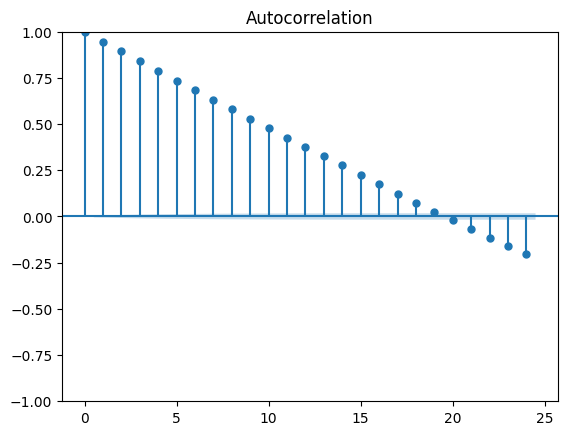

In [152]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['PersonalConsumptionExpenditures_normalized'].dropna(), lags=24)
plt.show()

In [153]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(
    df['PersonalConsumptionExpenditures_normalized'].dropna(),
    lags=[12],
    return_df=True
)

print(lb_test)

          lb_stat  lb_pvalue
12  889099.525184        0.0


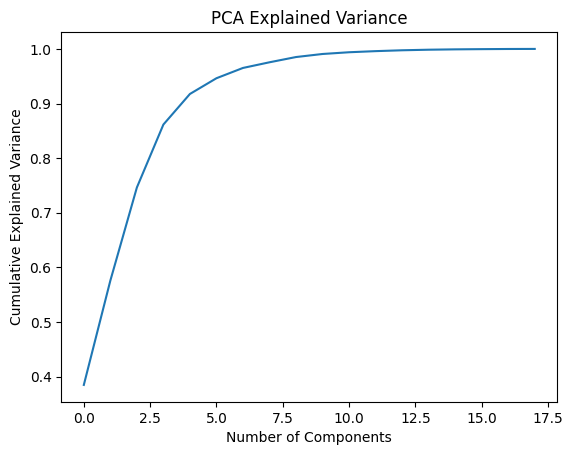

[3.84651472e-01 1.91033261e-01 1.70514860e-01 1.15314592e-01
 5.59938197e-02 2.88077402e-02 1.88402554e-02 1.03757703e-02
 9.60483026e-03 5.59334316e-03 3.17452414e-03 2.03508513e-03
 1.57866372e-03 1.03824302e-03 6.44446202e-04 3.89269478e-04
 2.91129711e-04 1.18695312e-04]


In [154]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = numeric_df.drop(columns=['PersonalConsumptionExpenditures_normalized'], errors='ignore')
X = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_

plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

print(explained_variance)

In [155]:
data["PCE_MOM"] = data["PersonalConsumptionExpenditures_normalized"].diff()
data["PCE_MOM_lag1"] = data["PCE_MOM"].shift(1)
data["PCE_MOM_lag2"] = data["PCE_MOM"].shift(2)
data["PCE_MOM_lag3"] = data["PCE_MOM"].shift(3)

target = "PCE_MOM"

In [163]:
# ------------------------------
# MAKE X VARIABLES STATIONARY
# ------------------------------

# 1. Create first differences for level-type macro variables
level_vars = [
    "ConsumerSentimentIndex_normalized_lag1",
    "Income_normalized_lag1",
    "Unemployment_normalized_lag1",
    "JoltsQuitsRate_normalized_lag1",
    "MonetaryCPI_normalized_lag1",
    "CrudeOilPrices_normalized_lag1",
    "ImportPriceIndex_normalized_lag1",
    "USNaturalGasCompositePrice_normalized_lag1",
    "CreditSpreadBAA_normalized_lag1",
    "CreditSpreadGS10_normalized_lag1"
]

for var in level_vars:
    data[var + "_diff"] = data[var].diff()

# 2. Keep already stationary momentum variables
momentum_vars = [
    "Real Sales MOM % - SA_normalized",
    "Transaction MOM % - SA_normalized",
    "PCE_MOM_lag1",
    "PCE_MOM_lag2",
    "PCE_MOM_lag3"
]

# 3. Final stationary X list (clean + defensible)
X_vars = (
    momentum_vars
    + [var + "_diff" for var in level_vars]
)


# # 4. Drop NA after differencing
model_df = data[X_vars + [target]].dropna().copy()

print("Final dataset shape:", model_df.shape)
print("Number of predictors:", len(X_vars))

model_df.head()

Final dataset shape: (80, 16)
Number of predictors: 15


,Real Sales MOM % - SA_normalized,Transaction MOM % - SA_normalized,PCE_MOM_lag1,PCE_MOM_lag2,PCE_MOM_lag3,ConsumerSentimentIndex_normalized_lag1_diff,Income_normalized_lag1_diff,Unemployment_normalized_lag1_diff,JoltsQuitsRate_normalized_lag1_diff,MonetaryCPI_normalized_lag1_diff,CrudeOilPrices_normalized_lag1_diff,ImportPriceIndex_normalized_lag1_diff,USNaturalGasCompositePrice_normalized_lag1_diff,CreditSpreadBAA_normalized_lag1_diff,CreditSpreadGS10_normalized_lag1_diff,PCE_MOM
5,-0.033448,-0.013116,0.008544,0.033149,0.026542,0.199930,0.004283,-0.049706,0.00000,0.002497,-0.170285,0.024428,-0.216253,-0.064602,-0.097392,0.005582
6,0.046468,-0.017735,0.005582,0.008544,0.033149,-0.128526,0.016526,0.000000,0.00000,-0.003290,-0.346078,-0.170999,-0.500086,-0.156890,-0.247226,0.015720
7,0.072726,0.030767,0.015720,0.005582,0.008544,0.014281,0.017867,0.049706,0.31022,0.023346,0.151494,0.000000,0.054063,-0.166119,-0.007492,0.005468
8,-0.125922,-0.070856,0.005468,0.015720,0.005582,-0.614069,0.040407,-0.049706,-0.31022,0.009275,-0.143169,-0.085499,-0.063074,-0.378381,-0.322143,0.007177
9,0.024776,-0.000028,0.007177,0.005468,0.015720,0.242772,0.019165,-0.049706,0.00000,0.015617,0.120108,0.012214,0.252296,0.036915,0.052442,0.020960


In [164]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Last 3 observations for OOS
train_df = model_df.iloc[:-3]
test_df  = model_df.iloc[-3:]

X_train = train_df[X_vars]
y_train = train_df[target]

X_test = test_df[X_vars]
y_test = test_df[target]

X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train_const).fit(
    cov_type="HAC",
    cov_kwds={"maxlags":3}
)

print(model.summary())

y_pred = model.predict(X_test_const)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("3-Month OOS RMSE:", rmse)
print("3-Month OOS R2:", r2)

                            OLS Regression Results                            
Dep. Variable:                PCE_MOM   R-squared:                       0.498
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     9.782
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           3.35e-11
Time:                        18:49:09   Log-Likelihood:                 191.54
No. Observations:                  77   AIC:                            -351.1
Df Residuals:                      61   BIC:                            -313.6
Df Model:                          15                                         
Covariance Type:                  HAC                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------

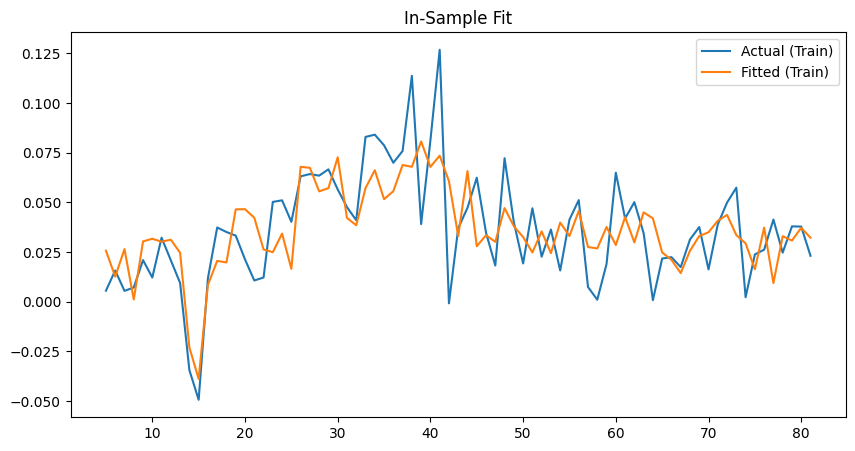

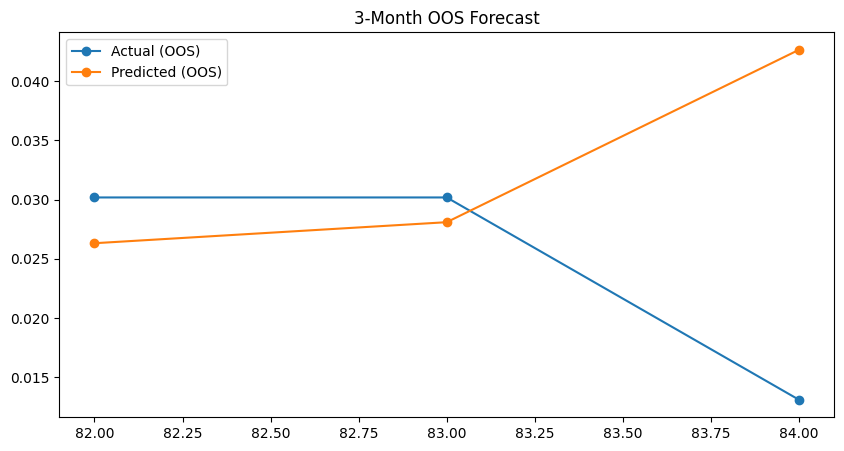

In [165]:
import matplotlib.pyplot as plt

# In-sample fitted
fitted = model.predict(X_train_const)

plt.figure(figsize=(10,5))
plt.plot(y_train.index, y_train, label="Actual (Train)")
plt.plot(y_train.index, fitted, label="Fitted (Train)")
plt.legend()
plt.title("In-Sample Fit")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, marker='o', label="Actual (OOS)")
plt.plot(y_test.index, y_pred, marker='o', label="Predicted (OOS)")
plt.legend()
plt.title("3-Month OOS Forecast")
plt.show()

In [166]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = model.resid
lb_test = acorr_ljungbox(residuals, lags=[3], return_df=True)
print(lb_test)

    lb_stat  lb_pvalue
3  1.708349   0.635079


In [167]:
from scipy.stats import jarque_bera

jb_stat, jb_p = jarque_bera(residuals)
print("JB p-value:", jb_p)

JB p-value: 0.6459995873688256


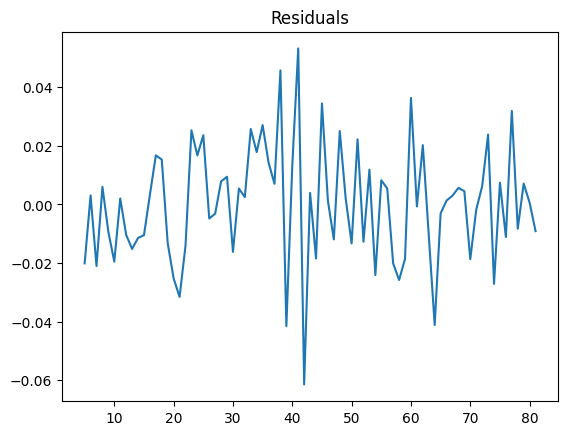

In [168]:
plt.plot(residuals)
plt.title("Residuals")
plt.show()

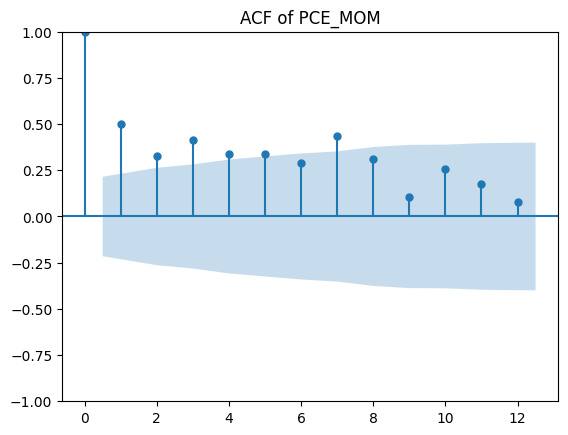

In [169]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(data["PCE_MOM"].dropna(), lags=12)
plt.title("ACF of PCE_MOM")
plt.show()

In [170]:
# Create AR lags
for i in range(1, 5):
    data[f"PCE_MOM_lag{i}"] = data["PCE_MOM"].shift(i)

In [173]:
# FSBI variables
fsbi_vars = [
    "Real Sales MOM % - SA_normalized",
    "Transaction MOM % - SA_normalized"
]

# AR variables
ar_vars = [
    "PCE_MOM_lag1",
    "PCE_MOM_lag2",
    "PCE_MOM_lag3",
    "PCE_MOM_lag4"
]

# Final X list
X_vars = ar_vars + fsbi_vars

target = "PCE_MOM"

In [174]:
model_df = data[X_vars + [target]].dropna().copy()

print("Final dataset shape:", model_df.shape)

Final dataset shape: (79, 7)


In [175]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Last 3 observations OOS
train_df = model_df.iloc[:-3]
test_df  = model_df.iloc[-3:]

X_train = train_df[X_vars]
y_train = train_df[target]

X_test = test_df[X_vars]
y_test = test_df[target]

# Add constant
X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

# Estimate model
model = sm.OLS(y_train, X_train_const).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 3}
)

print(model.summary())

# Forecast
y_pred = model.predict(X_test_const)

# OOS metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("AR + FSBI 3-Month OOS RMSE:", rmse)
print("AR + FSBI 3-Month OOS R2:", r2)

                            OLS Regression Results                            
Dep. Variable:                PCE_MOM   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                     6.580
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           1.57e-05
Time:                        18:56:45   Log-Likelihood:                 182.44
No. Observations:                  76   AIC:                            -350.9
Df Residuals:                      69   BIC:                            -334.6
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

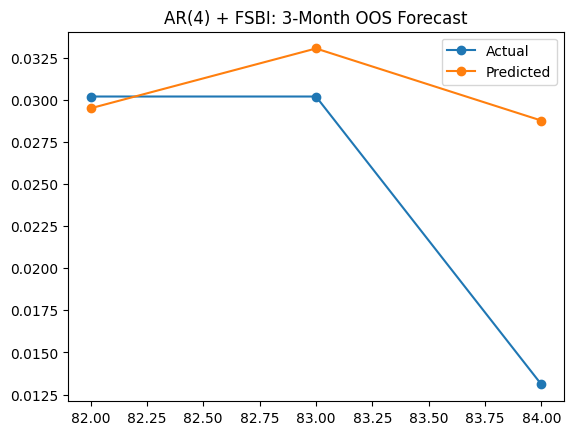

In [176]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test.index, y_test, marker="o", label="Actual")
plt.plot(y_test.index, y_pred, marker="o", label="Predicted")
plt.title("AR(4) + FSBI: 3-Month OOS Forecast")
plt.legend()
plt.show()

In [177]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import numpy as np

# -----------------------------
# 1. Create AR lags
# -----------------------------
for i in range(1, 4):
    data[f"PCE_MOM_lag{i}"] = data["PCE_MOM"].shift(i)

# -----------------------------
# 2. Create FSBI lags (Richmond-style)
# -----------------------------
data["RealSales_MOM_lag1"] = data["Real Sales MOM % - SA_normalized"].shift(1)
data["Transaction_MOM_lag1"] = data["Transaction MOM % - SA_normalized"].shift(1)

# -----------------------------
# 3. Define variables
# -----------------------------
target = "PCE_MOM"

ar_vars = [
    "PCE_MOM_lag1",
    "PCE_MOM_lag2",
    "PCE_MOM_lag3"
]

fsbi_vars = [
    "Real Sales MOM % - SA_normalized",
    "Transaction MOM % - SA_normalized",
    "RealSales_MOM_lag1",
    "Transaction_MOM_lag1"
]

# Build dataset
model_df = data[ar_vars + fsbi_vars + [target]].dropna().copy()

# -----------------------------
# 4. 3-Month OOS Split
# -----------------------------
train_df = model_df.iloc[:-3]
test_df  = model_df.iloc[-3:]

y_train = train_df[target]
y_test  = test_df[target]

# -----------------------------
# MODEL A: AR(3)
# -----------------------------
X_train_A = sm.add_constant(train_df[ar_vars])
X_test_A  = sm.add_constant(test_df[ar_vars])

model_A = sm.OLS(y_train, X_train_A).fit(cov_type="HAC", cov_kwds={"maxlags":3})
y_pred_A = model_A.predict(X_test_A)

rmse_A = np.sqrt(mean_squared_error(y_test, y_pred_A))

# -----------------------------
# MODEL B: AR(3) + FSBI
# -----------------------------
X_train_B = sm.add_constant(train_df[ar_vars + fsbi_vars])
X_test_B  = sm.add_constant(test_df[ar_vars + fsbi_vars])

model_B = sm.OLS(y_train, X_train_B).fit(cov_type="HAC", cov_kwds={"maxlags":3})
y_pred_B = model_B.predict(X_test_B)

rmse_B = np.sqrt(mean_squared_error(y_test, y_pred_B))

# -----------------------------
# 5. Compare Results
# -----------------------------
print("AR(3) OOS RMSE:", rmse_A)
print("AR(3) + FSBI OOS RMSE:", rmse_B)
print("RMSE Improvement (positive = FSBI helps):", rmse_A - rmse_B)

print("\n--- AR(3) Model Summary ---")
print(model_A.summary())

print("\n--- AR(3) + FSBI Model Summary ---")
print(model_B.summary())

AR(3) OOS RMSE: 0.0102457355004807
AR(3) + FSBI OOS RMSE: 0.009905912568872443
RMSE Improvement (positive = FSBI helps): 0.00033982293160825586

--- AR(3) Model Summary ---
                            OLS Regression Results                            
Dep. Variable:                PCE_MOM   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     9.251
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           2.92e-05
Time:                        12:18:17   Log-Likelihood:                 180.08
No. Observations:                  77   AIC:                            -352.2
Df Residuals:                      73   BIC:                            -342.8
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                   coef    std err   

In [179]:
print(train_df.columns)

Index(['PCE_MOM_lag1', 'PCE_MOM_lag2', 'PCE_MOM_lag3',
       'Real Sales MOM % - SA_normalized', 'Transaction MOM % - SA_normalized',
       'RealSales_MOM_lag1', 'Transaction_MOM_lag1', 'PCE_MOM'],
      dtype='object')
